## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 원자재 가격충격 패널 검증 EDA

`원자재_가격충격_패널.csv` — **내가 만든 지표가 정상인가**

원자료 검증과 다른 점: 구축 지표는 **참값이 없다**.
대신 만드는 과정에서 지켜져야 할 성질이 실제로 지켜졌는지를 본다.

| 단계 | 질문 |
|---|---|
| B1 | 패널이 의도한 모양인가 |
| B2 | 구축식이 보장해야 할 성질이 지켜졌는가 |
| B3 | 회귀가 쓸 수 있는 변동이 있는가 |
| B4 | 알려진 사건과 방향이 맞는가 |
| B5 | 소수 관측이 지표를 지배하는가 |
| B6 | 고정효과를 넣어도 변동이 남는가 |

## 준비

In [2]:
import pandas as pd, numpy as np, warnings
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        print(f"폰트: {f}")
        break
    except Exception:
        continue
mpl.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": .18,
                     "axes.spines.top": False, "axes.spines.right": False})

INK, WARN, OK, GREY = "#16202B", "#C1682E", "#2E6B5E", "#98A2AA"
PAL = [INK, OK, WARN, "#6B7783", "#A8B2B8"]

def ok_bad(cond, a, b):
    display(Markdown(f"**{'✅ 정상' if cond else '⚠️ 확인필요'}** — {a if cond else b}"))

def paint(df, col="판정", good="정상"):
    return df.style.map(
        lambda x: "background-color:#E4EFEB;color:#1F6152" if x == good
                  else "background-color:#F6E7E4;color:#8E3226", subset=[col])

폰트: Malgun Gothic


In [3]:
d = pd.read_csv(str(PROCESSED / "원자재_가격충격_패널.csv"), encoding="utf-8-sig")
BASE, EXT, DIFF = "shock_baseline_1111only", "shock_extended_1111_1119", "diff_1119_effect"

print(f"{len(d)}행   업종 {d['industry_code'].nunique()}개   "
      f"연도 {d['year'].min()}~{d['year'].max()}")
d.head(3)

440행   업종 40개   연도 2015~2025


,year,industry_code,shock_baseline_1111only,shock_extended_1111_1119,diff_1119_effect
0,2015,I3101,-1.101175,-1.101733,-0.000558
1,2015,I3102,-0.363899,-0.364057,-0.000158
2,2015,I3103,-0.495502,-0.495741,-0.000239


---
## B1 · 형식

In [4]:
n_i, n_y = d["industry_code"].nunique(), d["year"].nunique()
ok_bad(len(d) == n_i*n_y, f"{n_i}×{n_y}={n_i*n_y} 완전 균형",
       f"{n_i}×{n_y}={n_i*n_y} 인데 실제 {len(d)}행")
ok_bad(d.duplicated(["year", "industry_code"]).sum() == 0, "업종×연도 중복 없음", "중복")
ok_bad(d.isna().sum().sum() == 0, "결측 없음", f"결측 {d.isna().sum().sum()}건")
ok_bad(not np.isinf(d.select_dtypes(np.number)).any().any(), "무한대 없음", "무한대 존재")

display(d[[BASE, EXT, DIFF]].describe().T[["mean", "std", "min", "50%", "max"]].round(3))
mx = d[[BASE, EXT]].abs().max().max()
ok_bad(mx < 100, f"최대 절대값 {mx:.1f} — 가격변화율 가중합으로 상식 범위",
       f"최대 절대값 {mx:.1f} — 단위 오류 의심")

**✅ 정상** — 40×11=440 완전 균형

**✅ 정상** — 업종×연도 중복 없음

**✅ 정상** — 결측 없음

**✅ 정상** — 무한대 없음

,mean,std,min,50%,max
shock_baseline_1111only,0.189,3.353,-33.318,0.006,27.440
shock_extended_1111_1119,0.190,3.355,-33.318,0.007,27.441
diff_1119_effect,0.001,0.047,-0.506,0.000,0.628


**✅ 정상** — 최대 절대값 33.3 — 가격변화율 가중합으로 상식 범위

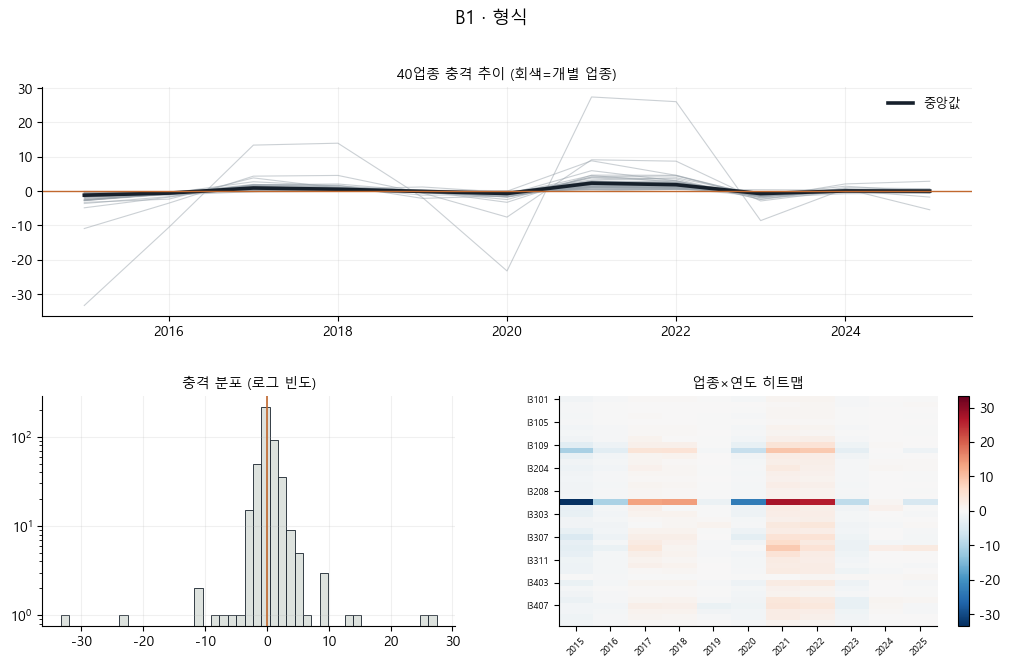

In [5]:
W = d.pivot(index="year", columns="industry_code", values=BASE)

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, :])
for c in W.columns:
    ax.plot(W.index, W[c], lw=.8, color=GREY, alpha=.5)
ax.plot(W.index, W.median(axis=1), lw=2.6, color=INK, label="중앙값")
ax.fill_between(W.index, W.quantile(.25, axis=1), W.quantile(.75, axis=1),
                alpha=.15, color=INK)
ax.axhline(0, color=WARN, lw=1)
ax.legend(frameon=False, fontsize=9)
ax.set_title("40업종 충격 추이 (회색=개별 업종)", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.hist(d[BASE], bins=45, color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(0, color=WARN, lw=1.2)
ax.set_yscale("log"); ax.set_title("충격 분포 (로그 빈도)", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(W.T, aspect="auto", cmap="RdBu_r",
               vmin=-np.abs(W.values).max(), vmax=np.abs(W.values).max())
ax.set_xticks(range(len(W.index))); ax.set_xticklabels(W.index, fontsize=7, rotation=45)
ax.set_yticks(range(0, len(W.columns), 4))
ax.set_yticklabels(W.columns[::4], fontsize=6.5)
plt.colorbar(im, ax=ax, fraction=.035)
ax.set_title("업종×연도 히트맵", fontsize=10); ax.grid(False)

plt.suptitle("B1 · 형식", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## B2 · 불변 성질

`diff = extended − baseline` 이 성립해야 하고,
확장(1119 추가)이 부호를 뒤집을 만큼 커서는 안 된다.

In [6]:
r = d[DIFF] - (d[EXT] - d[BASE])
ok_bad(r.abs().max() < 1e-9, f"diff 항등식 성립 (최대오차 {r.abs().max():.2e})",
       f"불일치 {r.abs().max():.6f}")

flip = d[d[BASE]*d[EXT] < 0]
ok_bad(len(flip) == 0, "부호 반전 0건", f"부호 반전 {len(flip)}건")

nz = d[d[BASE].abs() > 1e-6].copy()
nz["확장영향(%)"] = (nz[DIFF].abs()/nz[BASE].abs()*100)
display(Markdown("### 확장 영향 크기 |diff| / |baseline|"))
display(nz["확장영향(%)"].describe(percentiles=[.5, .9, .99]).round(3).to_frame().T)

big = nz[nz["확장영향(%)"] > 10]
display(Markdown(f"### 영향 10% 초과 {len(big)}건 — 업종 분포"))
display(big["industry_code"].value_counts().rename("건수").to_frame().T)
display(big.nlargest(6, "확장영향(%)")[["industry_code", "year", BASE, DIFF, "확장영향(%)"]]
        .round(3).reset_index(drop=True))

dom = big["industry_code"].value_counts()
if len(dom):
    ok_bad(dom.iloc[0] < len(big)*.5,
           "특정 업종 집중 없음",
           f"**{dom.index[0]}** 가 {dom.iloc[0]}/{len(big)}건 — 이 업종은 확장 여부가 값을 크게 바꿈")

**✅ 정상** — diff 항등식 성립 (최대오차 7.07e-15)

**✅ 정상** — 부호 반전 0건

### 확장 영향 크기 |diff| / |baseline|

,count,mean,std,min,50%,90%,99%,max
확장영향(%),440.0,1.58,7.269,0.0,0.09,1.247,43.62,75.392


### 영향 10% 초과 17건 — 업종 분포

industry_code,I3404,I3405,I3105,I3107,I3206,I3403,I3410
건수,10,2,1,1,1,1,1


,industry_code,year,shock_baseline_1111only,diff_1119_effect,확장영향(%)
0,I3404,2024,0.055,0.041,75.392
1,I3404,2019,-0.247,-0.167,67.778
2,I3404,2023,-0.874,-0.506,57.857
3,I3105,2019,-0.000,-0.000,50.005
4,I3404,2021,1.346,0.628,46.639
5,I3404,2022,1.152,0.448,38.898


**⚠️ 확인필요** — **I3404** 가 10/17건 — 이 업종은 확장 여부가 값을 크게 바꿈

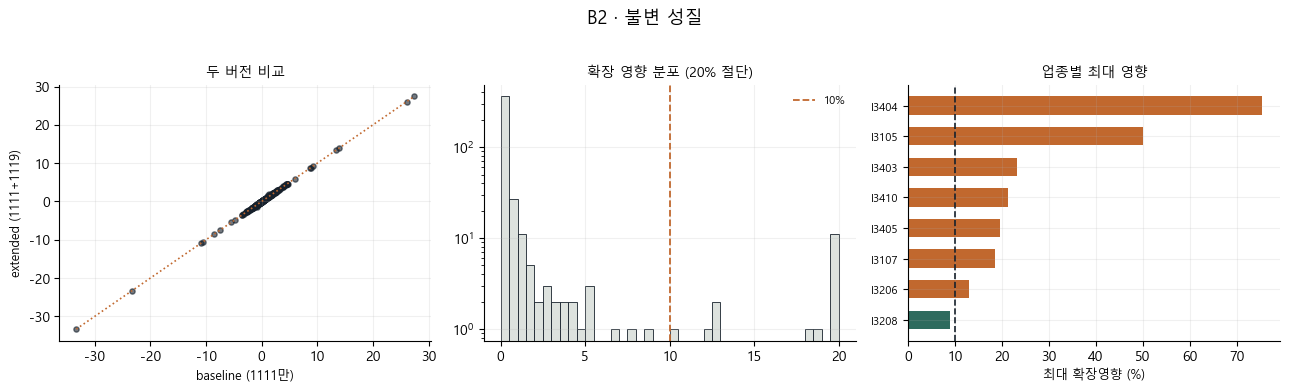

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.scatter(d[BASE], d[EXT], s=14, color=INK, alpha=.6)
lim = [d[BASE].min(), d[BASE].max()]
ax.plot(lim, lim, ls=":", color=WARN, lw=1.2)
ax.set_xlabel("baseline (1111만)", fontsize=9); ax.set_ylabel("extended (1111+1119)", fontsize=9)
ax.set_title("두 버전 비교", fontsize=10)

ax = axes[1]
ax.hist(nz["확장영향(%)"].clip(upper=20), bins=40,
        color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(10, ls="--", lw=1.3, color=WARN, label="10%")
ax.set_yscale("log"); ax.legend(frameon=False, fontsize=8)
ax.set_title("확장 영향 분포 (20% 절단)", fontsize=10)

ax = axes[2]
by_ind = nz.groupby("industry_code")["확장영향(%)"].max().nlargest(8)
ax.barh(by_ind.index[::-1], by_ind.values[::-1],
        color=[WARN if v > 10 else OK for v in by_ind.values[::-1]], height=.6)
ax.axvline(10, ls="--", lw=1.2, color=INK)
ax.set_xlabel("최대 확장영향 (%)", fontsize=9)
ax.set_title("업종별 최대 영향", fontsize=10); ax.tick_params(axis="y", labelsize=8)

plt.suptitle("B2 · 불변 성질", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## B3 · 변동

연도 성분이 압도적이면 연도 고정효과에 대부분 흡수된다.
업종 성분이 살아있어야 식별이 가능하다.

In [8]:
vt = d[BASE].var()
vy = d.groupby("year")[BASE].transform("mean").var()
vi = d.groupby("industry_code")[BASE].transform("mean").var()

V = pd.DataFrame([
    ("전체 분산", vt, 100.0),
    ("연도 평균의 분산", vy, vy/vt*100),
    ("업종 평균의 분산", vi, vi/vt*100),
], columns=["성분", "분산", "비중(%)"]).round(3)
display(V)
ok_bad(vi/vt > .01, f"업종 성분 {vi/vt*100:.1f}% — 식별 가능",
       f"업종 성분 {vi/vt*100:.1f}% — 거의 연도 공통")

Y = d.groupby("year")[BASE].agg(평균="mean", 표준편차="std",
                                최소="min", 최대="max").round(3)
display(Y)

Wp = d.pivot(index="industry_code", columns="year", values=BASE)
yrs = sorted(Wp.columns)
cors = pd.Series({f"{a}–{b}": Wp[a].corr(Wp[b], method="spearman")
                  for a, b in zip(yrs[:-1], yrs[1:])}).round(3)
display(Markdown("### 인접 연도 업종 순위 상관 (Spearman)"))
display(cors.to_frame("상관").T)
ok_bad(abs(cors.mean()) > .5,
       f"평균 {cors.mean():+.3f} — 업종 노출 순위가 안정적",
       f"평균 {cors.mean():+.3f} — 순위가 해마다 뒤집힘 → 시간불변 노출도로 쓰면 안 됨")

,성분,분산,비중(%)
0,전체 분산,11.240,100.000
1,연도 평균의 분산,2.874,25.572
2,업종 평균의 분산,0.054,0.483


**⚠️ 확인필요** — 업종 성분 0.5% — 거의 연도 공통

,평균,표준편차,최소,최대
year,,,,
2015,-2.569,5.294,-33.318,-0.078
2016,-0.949,1.681,-10.550,-0.163
2017,1.368,2.172,-0.197,13.411
2018,1.116,2.225,-0.052,13.966
2019,-0.184,0.537,-2.119,1.209
2020,-1.569,3.732,-23.259,0.144
2021,3.158,4.406,0.024,27.440
2022,2.749,4.086,0.477,26.068
2023,-1.115,1.404,-8.587,0.410


### 인접 연도 업종 순위 상관 (Spearman)

,2015–2016,2016–2017,2017–2018,2018–2019,2019–2020,2020–2021,2021–2022,2022–2023,2023–2024,2024–2025
상관,0.816,-0.721,0.716,-0.423,0.516,-0.632,0.958,-0.922,-0.269,0.088


**⚠️ 확인필요** — 평균 +0.013 — 순위가 해마다 뒤집힘 → 시간불변 노출도로 쓰면 안 됨

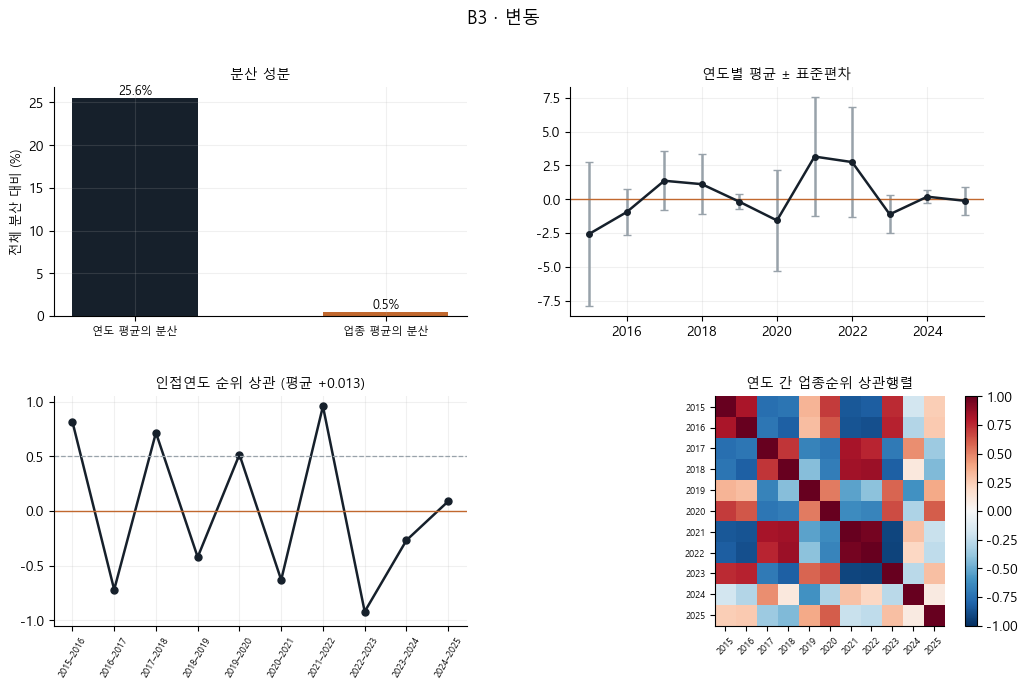

In [9]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, 0])
ax.bar(V["성분"][1:], V["비중(%)"][1:], width=.5, color=[INK, WARN])
for i, v in enumerate(V["비중(%)"][1:]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("전체 분산 대비 (%)", fontsize=9)
ax.set_title("분산 성분", fontsize=10); ax.tick_params(axis="x", labelsize=8)

ax = fig.add_subplot(gs[0, 1])
ax.errorbar(Y.index, Y["평균"], yerr=Y["표준편차"], fmt="o-", lw=1.8,
            color=INK, ecolor=GREY, capsize=3, ms=4)
ax.axhline(0, color=WARN, lw=1)
ax.set_title("연도별 평균 ± 표준편차", fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.plot(range(len(cors)), cors.values, "o-", lw=1.8, color=INK, ms=5)
ax.axhline(0, color=WARN, lw=1); ax.axhline(.5, ls="--", lw=.9, color=GREY)
ax.set_xticks(range(len(cors)))
ax.set_xticklabels(cors.index, fontsize=6.5, rotation=60)
ax.set_ylim(-1.05, 1.05)
ax.set_title(f"인접연도 순위 상관 (평균 {cors.mean():+.3f})", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(Wp.corr(method="spearman"), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(yrs))); ax.set_xticklabels(yrs, fontsize=6.5, rotation=45)
ax.set_yticks(range(len(yrs))); ax.set_yticklabels(yrs, fontsize=6.5)
plt.colorbar(im, ax=ax, fraction=.045)
ax.set_title("연도 간 업종순위 상관행렬", fontsize=10); ax.grid(False)

plt.suptitle("B3 · 변동", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## B4 · 외부 정합성

In [10]:
known = {2015: "국제유가 급락", 2016: "유가 저점", 2020: "코로나 수요 붕괴",
         2021: "회복기 원자재 반등", 2022: "우크라이나 전쟁", 2023: "원자재가 조정"}
ym = d.groupby("year")[BASE].mean().round(3)
E = ym.to_frame("평균충격")
E["알려진 사건"] = [known.get(y, "") for y in E.index]
E["방향"] = np.where(E["평균충격"] > 0, "＋", "－")
display(E)

ok_bad(ym.get(2015, 0) < 0 and ym.get(2022, 0) > 0,
       "유가 급락기 음수, 전쟁기 양수 — 방향 일치", "기대 방향과 불일치")

display(Markdown("### 2022년 충격 상위/하위"))
y22 = d[d["year"] == 2022]
display(pd.concat([
    y22.nlargest(6, BASE)[["industry_code", BASE]].assign(구분="상위"),
    y22.nsmallest(5, BASE)[["industry_code", BASE]].assign(구분="하위"),
]).round(3).reset_index(drop=True))

,평균충격,알려진 사건,방향
year,,,
2015,-2.569,국제유가 급락,－
2016,-0.949,유가 저점,－
2017,1.368,,＋
2018,1.116,,＋
2019,-0.184,,－
2020,-1.569,코로나 수요 붕괴,－
2021,3.158,회복기 원자재 반등,＋
2022,2.749,우크라이나 전쟁,＋
2023,-1.115,원자재가 조정,－


**✅ 정상** — 유가 급락기 음수, 전쟁기 양수 — 방향 일치

### 2022년 충격 상위/하위

,industry_code,shock_baseline_1111only,구분
0,I3301,26.068,상위
1,I3201,8.729,상위
2,I3307,4.612,상위
3,I3309,4.610,상위
4,I3109,4.427,상위
5,I3305,3.902,상위
6,I3105,0.477,하위
7,I3402,0.543,하위
8,I3102,0.587,하위
9,I3104,0.613,하위


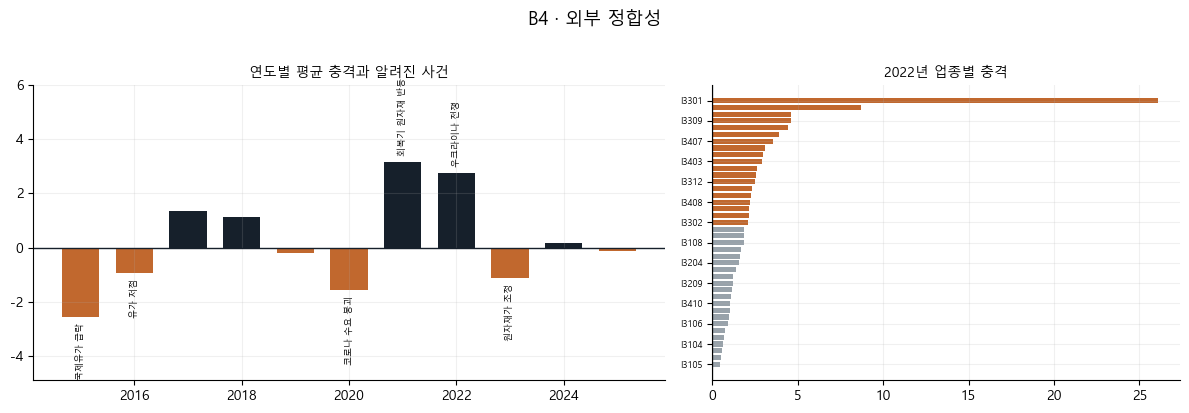

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
ax.bar(ym.index, ym.values, width=.7,
       color=[INK if v > 0 else WARN for v in ym.values])
ax.axhline(0, color=INK, lw=1)
for y, v in ym.items():
    if y in known:
        ax.annotate(known[y], (y, v), fontsize=6.5, rotation=90,
                    ha="center", va="bottom" if v > 0 else "top",
                    xytext=(0, 4 if v > 0 else -4), textcoords="offset points")
ax.set_ylim(ym.min()*1.9, ym.max()*1.9)
ax.set_title("연도별 평균 충격과 알려진 사건", fontsize=10)

ax = axes[1]
srt = y22.sort_values(BASE)
ax.barh(range(len(srt)), srt[BASE],
        color=[WARN if v > 2 else GREY for v in srt[BASE]], height=.75)
ax.set_yticks(range(0, len(srt), 3))
ax.set_yticklabels(srt["industry_code"].iloc[::3], fontsize=6.5)
ax.axvline(0, color=INK, lw=.9)
ax.set_title("2022년 업종별 충격", fontsize=10)

plt.suptitle("B4 · 외부 정합성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## B5 · 영향력

In [12]:
a = d[BASE].abs().sort_values(ascending=False)
C = pd.DataFrame([(f"상위 {k}%", int(len(a)*k/100),
                   round(a.head(max(1, int(len(a)*k/100))).sum()/a.sum()*100, 1))
                  for k in [1, 5, 10, 25]],
                 columns=["구간", "관측수", "절대합 기여(%)"])
display(C)

display(Markdown("### 극단 관측 상위 8"))
display(d.reindex(a.index).head(8)[["industry_code", "year", BASE]]
        .round(3).reset_index(drop=True))

mabs = d.groupby("industry_code")[BASE].apply(lambda x: x.abs().mean()).sort_values()
display(Markdown("### 업종별 평균 절대충격 — 상위 5 / 하위 5"))
display(pd.concat([mabs.tail(5)[::-1].rename("상위"),
                   mabs.head(5).rename("하위")], axis=1).round(3))

base_ym = d.groupby("year")[BASE].mean()
loo = pd.Series({i: (d[d["industry_code"] != i].groupby("year")[BASE].mean()
                     - base_ym).abs().max()
                 for i in d["industry_code"].unique()}).sort_values(ascending=False)
display(Markdown("### leave-one-out — 업종 하나 빼면 연도평균이 얼마나 움직이나"))
display(loo.head(5).round(4).to_frame("최대 변동"))
ok_bad(loo.iloc[0] < loo.iloc[1]*2,
       "특정 업종 지배 없음",
       f"**{loo.index[0]}** 가 지배 — 이 업종 제외 강건성 검정 필요")

,구간,관측수,절대합 기여(%)
0,상위 1%,4,17.5
1,상위 5%,22,39.1
2,상위 10%,44,50.8
3,상위 25%,110,72.3


### 극단 관측 상위 8

,industry_code,year,shock_baseline_1111only
0,I3301,2015,-33.318
1,I3301,2021,27.440
2,I3301,2022,26.068
3,I3301,2020,-23.259
4,I3301,2018,13.966
5,I3301,2017,13.411
6,I3201,2015,-10.899
7,I3301,2016,-10.550


### 업종별 평균 절대충격 — 상위 5 / 하위 5

,상위,하위
industry_code,,
I3301,14.961,NaN
I3201,4.920,NaN
I3309,2.844,NaN
I3307,2.299,NaN
I3109,1.966,NaN
I3105,NaN,0.211
I3402,NaN,0.235
I3102,NaN,0.262
I3103,NaN,0.285


### leave-one-out — 업종 하나 빼면 연도평균이 얼마나 움직이나

,최대 변동
I3301,0.7884
I3201,0.2136
I3309,0.1457
I3402,0.0804
I3308,0.0720


**⚠️ 확인필요** — **I3301** 가 지배 — 이 업종 제외 강건성 검정 필요

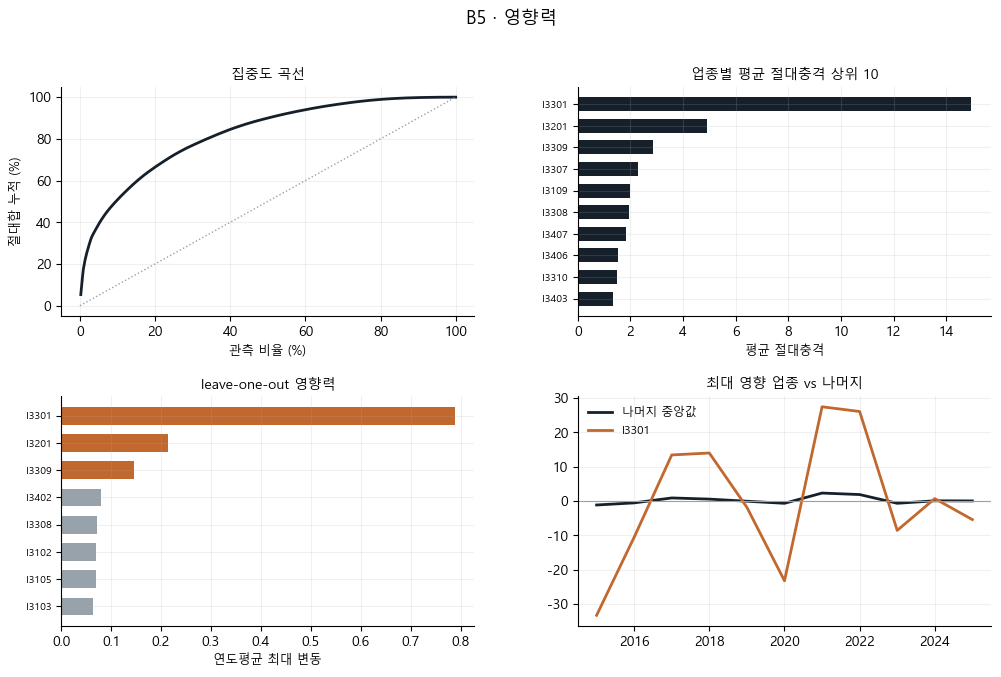

In [13]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 2, hspace=.35, wspace=.25)

ax = fig.add_subplot(gs[0, 0])
cum = a.cumsum()/a.sum()*100
ax.plot(np.arange(1, len(cum)+1)/len(cum)*100, cum.values, lw=2, color=INK)
ax.plot([0, 100], [0, 100], ls=":", color=GREY, lw=1)
ax.set_xlabel("관측 비율 (%)", fontsize=9); ax.set_ylabel("절대합 누적 (%)", fontsize=9)
ax.set_title("집중도 곡선", fontsize=10)

ax = fig.add_subplot(gs[0, 1])
ax.barh(mabs.tail(10).index, mabs.tail(10).values, color=INK, height=.65)
ax.set_xlabel("평균 절대충격", fontsize=9)
ax.set_title("업종별 평균 절대충격 상위 10", fontsize=10)
ax.tick_params(axis="y", labelsize=7.5)

ax = fig.add_subplot(gs[1, 0])
ax.barh(loo.head(8).index[::-1], loo.head(8).values[::-1],
        color=[WARN if v > loo.median()*3 else GREY for v in loo.head(8).values[::-1]],
        height=.65)
ax.set_xlabel("연도평균 최대 변동", fontsize=9)
ax.set_title("leave-one-out 영향력", fontsize=10); ax.tick_params(axis="y", labelsize=7.5)

ax = fig.add_subplot(gs[1, 1])
top_i = mabs.index[-1]
ax.plot(W.index, W.drop(columns=top_i).median(axis=1), lw=2, color=INK, label="나머지 중앙값")
ax.plot(W.index, W[top_i], lw=2, color=WARN, label=top_i)
ax.axhline(0, color=GREY, lw=.8); ax.legend(frameon=False, fontsize=8.5)
ax.set_title(f"최대 영향 업종 vs 나머지", fontsize=10)

plt.suptitle("B5 · 영향력", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## B6 · 고정효과 흡수

가장 중요한 단계. 업종FE·연도FE를 넣은 회귀에서 이 변수가 살아남는지 본다.
잔여 변동이 거의 없으면 계수가 소수 관측으로만 식별되어 불안정해진다.

In [14]:
x = d.pivot(index="industry_code", columns="year", values=BASE)
dm = x.sub(x.mean(axis=1), axis=0).sub(x.mean(axis=0), axis=1) + x.values.mean()

v0, v1 = np.nanvar(x.values), np.nanvar(dm.values)
display(pd.DataFrame([
    ("원 분산", round(v0, 4), "100.0%"),
    ("업종·연도 평균 제거 후", round(v1, 4), f"{v1/v0*100:.1f}%"),
], columns=["구분", "분산", "비중"]))

ok_bad(v1/v0 > .05, f"{v1/v0*100:.1f}% 잔존 — 고정효과 하에서 식별 가능",
       f"{v1/v0*100:.1f}%만 잔존 — 거의 흡수됨")

res = dm.stack().reset_index(name="잔여")
display(Markdown("### 잔여 변동이 큰 관측 상위 8 — 이 관측들이 계수를 결정한다"))
display(res.reindex(res["잔여"].abs().sort_values(ascending=False).index)
        .head(8).round(3).reset_index(drop=True))

,구분,분산,비중
0,원 분산,11.2140,100.0%
1,업종·연도 평균 제거 후,8.2922,73.9%


**✅ 정상** — 73.9% 잔존 — 고정효과 하에서 식별 가능

### 잔여 변동이 큰 관측 상위 8 — 이 관측들이 계수를 결정한다

,industry_code,year,잔여
0,I3301,2015,-30.429
1,I3301,2021,24.602
2,I3301,2022,23.639
3,I3301,2020,-21.370
4,I3301,2018,13.170
5,I3301,2017,12.363
6,I3301,2016,-9.281
7,I3201,2015,-8.132


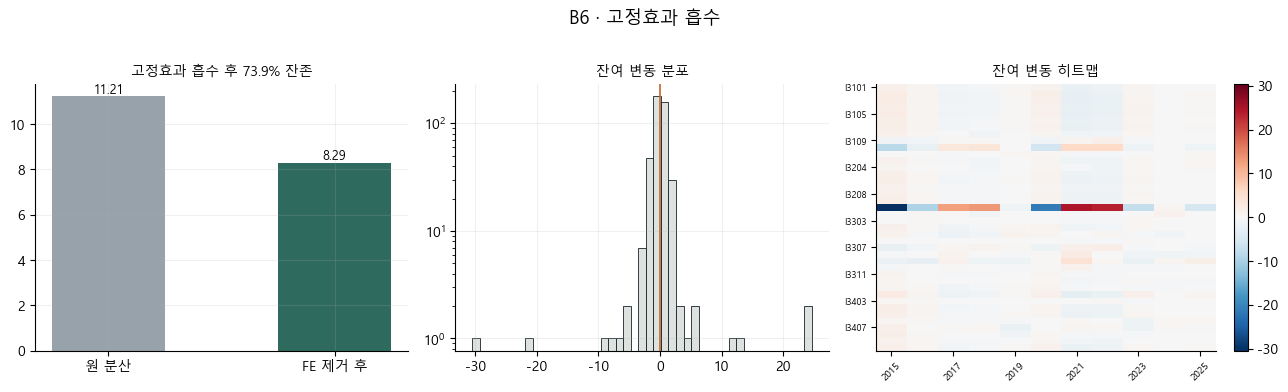

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ax = axes[0]
ax.bar(["원 분산", "FE 제거 후"], [v0, v1], width=.5,
       color=[GREY, OK if v1/v0 > .05 else WARN])
for i, v in enumerate([v0, v1]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_title(f"고정효과 흡수 후 {v1/v0*100:.1f}% 잔존", fontsize=10)

ax = axes[1]
mabs_ = np.abs(dm.values.flatten())
ax.hist(dm.values.flatten(), bins=45, color="#DDE2DE", edgecolor=INK, linewidth=.6)
ax.axvline(0, color=WARN, lw=1.2); ax.set_yscale("log")
ax.set_title("잔여 변동 분포", fontsize=10)

ax = axes[2]
im = ax.imshow(dm, aspect="auto", cmap="RdBu_r",
               vmin=-np.nanmax(np.abs(dm.values)), vmax=np.nanmax(np.abs(dm.values)))
ax.set_xticks(range(0, len(dm.columns), 2))
ax.set_xticklabels(dm.columns[::2], fontsize=7, rotation=45)
ax.set_yticks(range(0, len(dm.index), 4))
ax.set_yticklabels(dm.index[::4], fontsize=6.5)
plt.colorbar(im, ax=ax, fraction=.04)
ax.set_title("잔여 변동 히트맵", fontsize=10); ax.grid(False)

plt.suptitle("B6 · 고정효과 흡수", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 종합

In [16]:
S = pd.DataFrame([
    ("B1 형식", f"{n_i}×{n_y}={len(d)}행 완전균형, 결측 0", "정상"),
    ("B2 불변", f"diff 항등식 성립, 부호반전 0건 / 확장영향 10% 초과 {len(big)}건",
     "정상" if len(big) < len(nz)*.05 else "확인필요"),
    ("B3 변동", f"업종 성분 {vi/vt*100:.1f}%, 인접연도 순위상관 평균 {cors.mean():+.3f}",
     "확인필요"),
    ("B4 외부", "유가 급락기 음수, 전쟁기 양수 — 방향 일치", "정상"),
    ("B5 영향", f"상위 1%가 절대합의 {C.iloc[0,2]:.1f}%, 최대영향 업종 {loo.index[0]}",
     "확인필요"),
    ("B6 흡수", f"FE 제거 후 {v1/v0*100:.1f}% 잔존", "정상"),
], columns=["단계", "내용", "판정"])
display(paint(S))

display(Markdown(f"""
### 회귀 투입 판단

**투입 가능**하다. B6에서 {v1/v0*100:.1f}%가 잔존하므로 업종FE·연도FE 하에서 식별된다.

다만 강건성 검정에 두 가지를 넣어야 한다.

1. **{loo.index[0]} 제외 버전** — 지표를 지배하는 업종
2. **확장 여부 (1111만 vs 1111+1119)** — {dom.index[0] if len(dom) else "일부 업종"}에서 값이 크게 달라짐

### 사용상 제약

인접 연도 순위 상관 평균이 **{cors.mean():+.3f}** 로 불안정하다.
원자재 가격이 오를 때와 내릴 때 노출 업종 순위가 뒤집히기 때문이다.
따라서 이 변수는 **업종×연도 통제변수로만 쓰고,
시간불변 노출도(사전기간 평균)로 만들어 쓰면 안 된다.**
"""))

,단계,내용,판정
0,B1 형식,"40×11=440행 완전균형, 결측 0",정상
1,B2 불변,"diff 항등식 성립, 부호반전 0건 / 확장영향 10% 초과 17건",정상
2,B3 변동,"업종 성분 0.5%, 인접연도 순위상관 평균 +0.013",확인필요
3,B4 외부,"유가 급락기 음수, 전쟁기 양수 — 방향 일치",정상
4,B5 영향,"상위 1%가 절대합의 17.5%, 최대영향 업종 I3301",확인필요
5,B6 흡수,FE 제거 후 73.9% 잔존,정상



### 회귀 투입 판단

**투입 가능**하다. B6에서 73.9%가 잔존하므로 업종FE·연도FE 하에서 식별된다.

다만 강건성 검정에 두 가지를 넣어야 한다.

1. **I3301 제외 버전** — 지표를 지배하는 업종
2. **확장 여부 (1111만 vs 1111+1119)** — I3404에서 값이 크게 달라짐

### 사용상 제약

인접 연도 순위 상관 평균이 **+0.013** 로 불안정하다.
원자재 가격이 오를 때와 내릴 때 노출 업종 순위가 뒤집히기 때문이다.
따라서 이 변수는 **업종×연도 통제변수로만 쓰고,
시간불변 노출도(사전기간 평균)로 만들어 쓰면 안 된다.**
